# Eksplorativna analiza slika

## Struktura skupa podataka

- Ukupno slika:
- Broj slika za spring:
- Broj slika za summer:
- Broj slika za autumn:
- Broj slika za winter:

- Train:
- Test:
- Val:

## Primeri slika iz svake sezone

S obzirom da ne postoje gotove oznake, svaka slika je ručno klasifikovana na osnovu dosadašnjeg iskustva, pročitane literature i ličnog osećaja. Neke karakterisitike koje su se gledale i na osnovu kojih je moguće odrediti godišnje doba su:

🌸 **Proleće** – rumenija koža, svetlija kosa i svetlije oči  
☀️ **Leto** – bleda koža, svetle oči, ponekad pepeljasta kosa  
🍂 **Jesen** – žućkast ten, često crvenkasta ili riđa kosa  
❄️ **Zima** – tamnija koža, tamna kosa i tamne oči  


In [4]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from pathlib import Path
import os
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
from sklearn.metrics import classification_report, confusion_matrix
from tqdm import tqdm
import multiprocessing

import sys
sys.path.append(os.path.join(os.getcwd(), 'src'))
from face_extractor import FaceExtractor


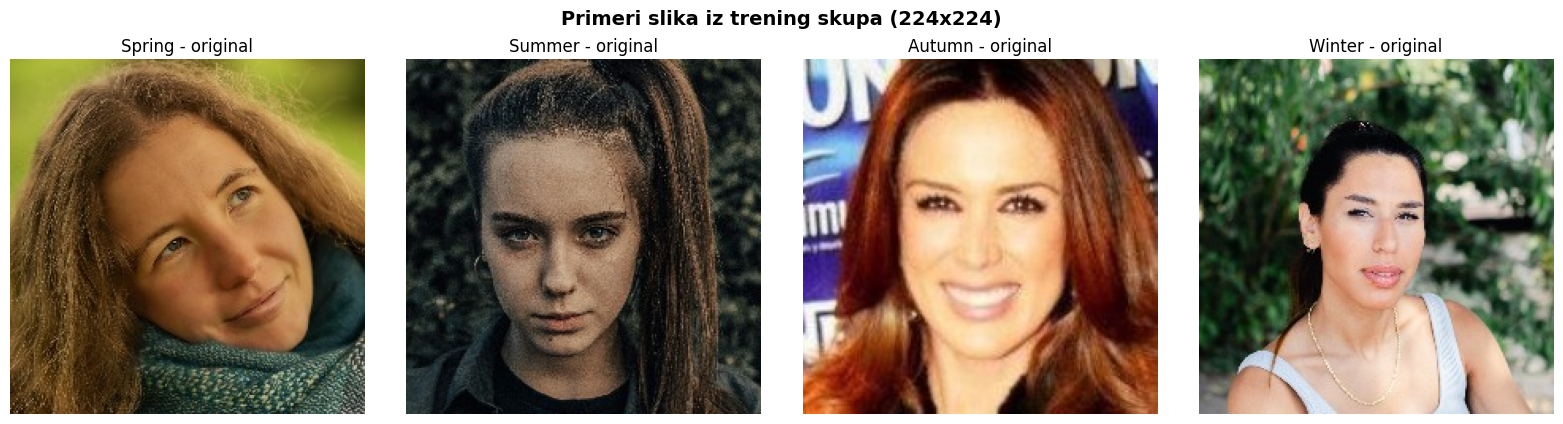

In [5]:

plt.figure(figsize=(16, 8))

for i, sezona in enumerate(['spring', 'summer', 'autumn', 'winter']):

    train_path = f"data/train/{sezona}"
    if os.path.exists(train_path) and len(os.listdir(train_path)) > 0:
        img_name = os.listdir(train_path)[0]
        img_path = f"{train_path}/{img_name}"

        img = cv2.imread(img_path)
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        plt.subplot(2, 4, i+1)
        plt.imshow(img_rgb)
        plt.title(f'{sezona.capitalize()} - original', fontsize=12)
        plt.axis('off')


plt.suptitle('Primeri slika iz trening skupa (224x224)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## FaceExtractor - Izdvajanje regiona lica

Za potrebe projekta razvijena je klasa `FaceExtractor` koja koristi **MediaPipe Face Mesh** za detekciju 468 ključnih tačaka na licu. Na osnovu ovih tačaka izdvajaju se regioni:

- **Koža lica** - formiranjem ovala lica i uklanjanjem očiju i usana
- **Oči** - pojedinačno levo i desno oko
- **Kosa** - procena regiona iznad čela

### Performanse izdvajanja
- **Koža i oči** - izdvajaju se vrlo precizno
- **Kosa** - izdvajanje je slabije i predstavlja izazov (varijacije u frizurama, bojama, pozadini)

Izdvojeni regioni će se koristiti za treniranje CNN modela kako bi se ispitalo da li specijalizovani regioni (koža, kosa, oči) mogu poboljšati klasifikaciju sezonskih tipova u odnosu na modele trenirane na celoj slici.

W0000 00:00:1774259089.134661   13503 face_landmarker_graph.cc:174] Sets FaceBlendshapesGraph acceleration to xnnpack by default.
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1774259089.158277   13509 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1774259089.175062   13517 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


FaceExtractor kreiran
 Lice detektovano
   - Piksela kože: 7491
   - Piksela kose: 1584
   - Levo oko: (27, 27, 3)
   - Desno oko: (24, 32, 3)


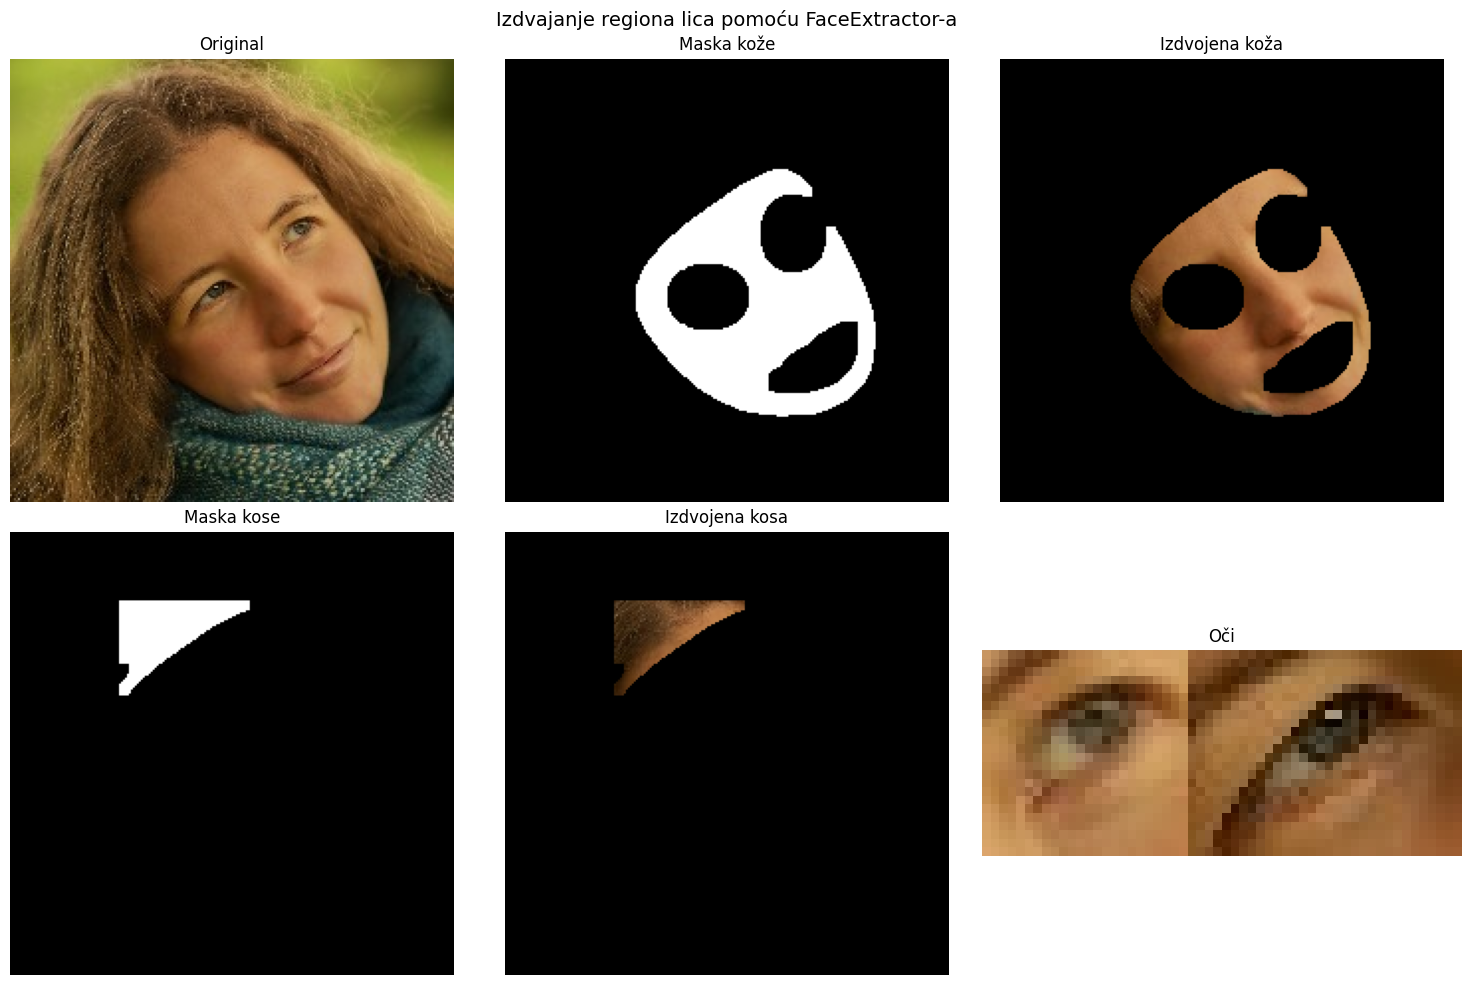

In [6]:
extractor = FaceExtractor()
print("FaceExtractor kreiran")

test_path = "data/train/spring/" + os.listdir("data/train/spring")[0]
result = extractor.extract_features(test_path, visualize=False)

if result:
    print(f" Lice detektovano")
    print(f"   - Piksela kože: {len(result['skin_pixels'])}")
    print(f"   - Piksela kose: {len(result['hair_pixels'])}")
    print(f"   - Levo oko: {result['left_eye'].shape}")
    print(f"   - Desno oko: {result['right_eye'].shape}")

if result:
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))


    axes[0, 0].imshow(cv2.cvtColor(result['original_image'], cv2.COLOR_BGR2RGB))
    axes[0, 0].set_title('Original')
    axes[0, 0].axis('off')


    axes[0, 1].imshow(result['skin_mask'], cmap='gray')
    axes[0, 1].set_title('Maska kože')
    axes[0, 1].axis('off')


    skin_only = cv2.bitwise_and(result['original_image'], result['original_image'], mask=result['skin_mask'])
    axes[0, 2].imshow(cv2.cvtColor(skin_only, cv2.COLOR_BGR2RGB))
    axes[0, 2].set_title('Izdvojena koža')
    axes[0, 2].axis('off')


    axes[1, 0].imshow(result['hair_mask'], cmap='gray')
    axes[1, 0].set_title('Maska kose')
    axes[1, 0].axis('off')


    hair_only = cv2.bitwise_and(result['original_image'], result['original_image'], mask=result['hair_mask'])
    axes[1, 1].imshow(cv2.cvtColor(hair_only, cv2.COLOR_BGR2RGB))
    axes[1, 1].set_title('Izdvojena kosa')
    axes[1, 1].axis('off')


    if result['left_eye'].size > 0 and result['right_eye'].size > 0:
        left = result['left_eye']
        right = result['right_eye']


        target_h = min(left.shape[0], right.shape[0])
        if left.shape[0] != target_h:
            new_w = int(left.shape[1] * target_h / left.shape[0])
            left = cv2.resize(left, (new_w, target_h))
        if right.shape[0] != target_h:
            new_w = int(right.shape[1] * target_h / right.shape[0])
            right = cv2.resize(right, (new_w, target_h))

        combined_eyes = np.hstack([left, right])
        axes[1, 2].imshow(cv2.cvtColor(combined_eyes, cv2.COLOR_BGR2RGB))
        axes[1, 2].set_title('Oči')
        axes[1, 2].axis('off')

    plt.suptitle('Izdvajanje regiona lica pomoću FaceExtractor-a', fontsize=14)
    plt.tight_layout()
    plt.show()